# Exploratory Data Analysis (EDA): Credit Card Fraud Detection

**Objective:** 
The purpose of this notebook is to deeply understand the underlying patterns in the Kaggle Credit Card Fraud dataset before applying any machine learning models. 

**Key areas of investigation:**
1. Overall data structure and missing values.
2. The severity of the class imbalance (Fraud vs. Normal).
3. The distribution of the unscaled features (`Time` and `Amount`).
4. Feature correlations to identify which PCA-transformed variables most heavily influence fraud.


In [7]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for professional plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

import warnings
warnings.filterwarnings('ignore')

## 1. Data Ingestion & Initial Inspection
First, we load the raw dataset. Because this dataset contains European credit card transactions from a two-day period, we expect a massive volume of transactions. Let's inspect the data types to ensure they are optimized for memory.


In [11]:
df = pd.read_csv('../data/raw/creditcard.csv')

print(df.head(5))

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [13]:
#Check data types and memory usage
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [15]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## 2. Data Quality Check
Before analyzing patterns, we must verify the integrity of the data. Machine learning models require clean data; missing values can cause algorithms to fail, and massive amounts of duplicates can skew our evaluation metrics.


In [22]:
df.shape

(283726, 31)

In [20]:
# Check for missing values
missing_values = df.isnull().sum().max()
print(f"Maximum missing values in any column: {missing_values}")

#Check for exact duplicates
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Maximum missing values in any column: 0
Number of duplicate rows: 1081


In [23]:
print("Dropping duplicate values:")
df = df.drop_duplicates()
print(f"New dataset shape: {df.shape}")

Dropping duplicate values:
New dataset shape: (283726, 31)


## 3. The Core Challenge: Class Imbalance
In fraud detection, the vast majority of transactions are legitimate. If a model predicts "Not Fraud" 100% of the time, it might achieve 99.8% accuracy, but it would be completely useless to a bank. 

Let's visualize exactly how imbalanced this dataset is to justify our future use of techniques like SMOTE or Precision-Recall curves.


In [28]:
# calculate exact distribution
class_counts = df['Class'].value_counts()
fraud_percentage = (class_counts[1] / class_counts.sum()) * 100

print(f"Normal Transactions: {class_counts[0]}")
print(f"Fraudulent Transactions: {class_counts[1]}")
print(f"Percentage of Fraud: {fraud_percentage:.3f}%")

Normal Transactions: 283253
Fraudulent Transactions: 473
Percentage of Fraud: 0.167%


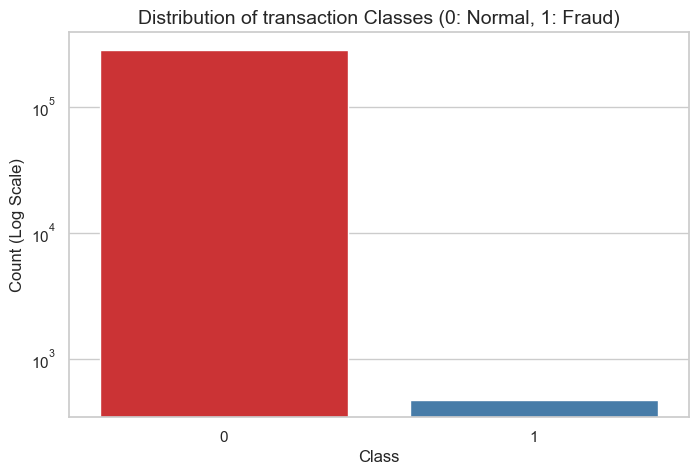

In [35]:
# Visualize the imbalance
plt.figure(figsize=(8,5))
ax = sns.countplot(x='Class', data=df, palette='Set1')
plt.title('Distribution of transaction Classes (0: Normal, 1: Fraud)', fontsize=14)
plt.yscale('log') # Using log scale because the difference is so massive
plt.ylabel('Count (Log Scale)')
plt.show()

## 4. Analyzing Unscaled Features (`Time` and `Amount`)
For confidentiality, variables `V1` through `V28` have been transformed using PCA (Principal Component Analysis) and are already scaled. 

However, `Time` (seconds elapsed since the first transaction) and `Amount` (transaction value) are in their original forms. Let's look at their distributions to decide how to scale them in our preprocessing pipeline.


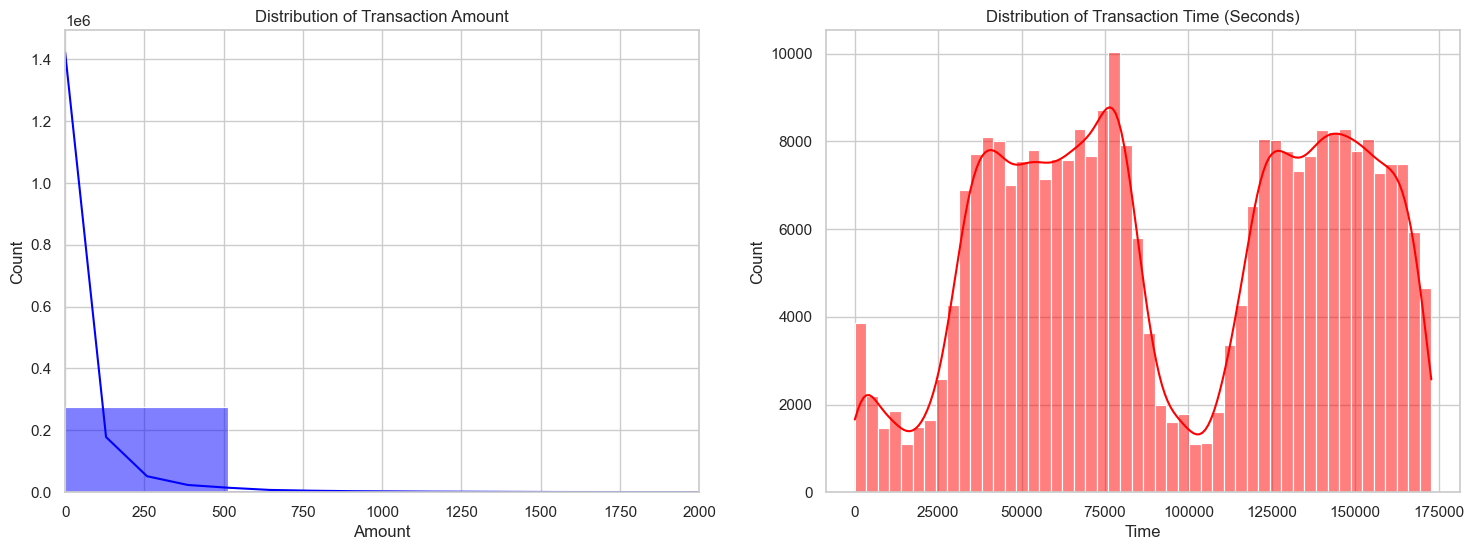

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(18,6))

# Distribution of Transaction Amount
sns.histplot(df['Amount'], bins=50, ax=ax[0], color='blue', kde=True)
ax[0].set_title('Distribution of Transaction Amount')
ax[0].set_xlim([0, 2000]) # Zooming in, as most transactions are small

# Distribution of Transaction Time
sns.histplot(df['Time'], bins=50, ax=ax[1], color='red', kde=True)
ax[1].set_title('Distribution of Transaction Time (Seconds)')

plt.show()

In [43]:

# Deep dive into fraud amounts
print("Fraudulent Transaction Amounts summary:")
print(df[df['Class'] == 1]['Amount'].describe())

Fraudulent Transaction Amounts summary:
count     473.000000
mean      123.871860
std       260.211041
min         0.000000
25%         1.000000
50%         9.820000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


## 5. Feature Correlation (Understanding What Drives Fraud)
We want to see if any specific PCA features heavily correlate with the `Class` target variable. 
* Negative correlation: Lower feature value -> Higher chance of fraud.
* Positive correlation: Higher feature value -> Higher chance of fraud.


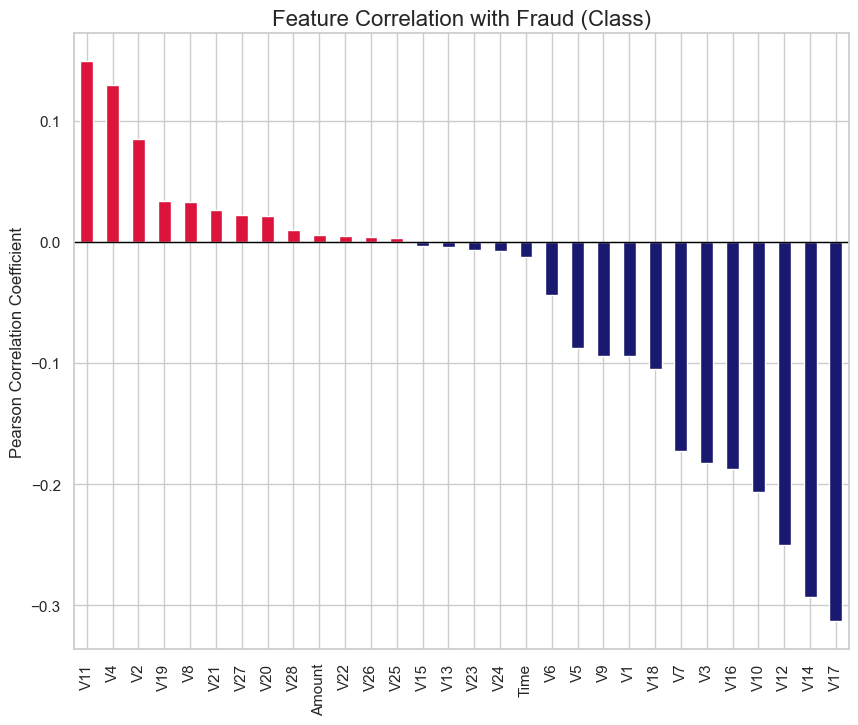

In [45]:
# Calculate correlation matrix
corr_matrix = df.corr()

class_corr = corr_matrix['Class'].sort_values(ascending=False)

plt.figure(figsize=(10,8))
# Bar plot for clearer visibility of target correlation
class_corr.drop('Class').plot(kind='bar', color=np.where(class_corr.drop('Class')>0,'crimson','midnightblue'))
plt.title('Feature Correlation with Fraud (Class)', fontsize=16)
plt.ylabel('Pearson Correlation Coefficient')
plt.axhline(0, color='black',linewidth=1)
plt.show()

## 🎯 Key Findings & Next Steps (Executive Summary)

1. **Perfect Data Quality**: There are no missing values. We removed a small number of duplicated rows.
2. **Extreme Class Imbalance**: Fraud represents less than **0.2%** of the data. We cannot use Accuracy as our metric. We must use Precision-Recall and apply techniques like SMOTE (Synthetic Minority Over-sampling Technique) or class weighting during modeling.
3. **Scaling Required**: The `Amount` and `Time` features are heavily skewed and unscaled. **Next Step:** We will apply a `RobustScaler` in our preprocessing pipeline. Unlike StandardScaler, RobustScaler is immune to extreme outliers, which are common in credit card fraud.
4. **Strong Predictors**: Features like `V14`, `V12`, and `V17` have strong negative correlations with fraud, meaning they will be highly critical to our tree-based models later.